Name-Rushi Raviraj Gujarathi || Roll no-17 || PRN no-1252090017


Use the diabetes data set from UCI and Pima Indians Diabetes data set for performing the following:
   
  a. Univariate analysis: Frequency, Mean, Median, Mode, Variance, Standard Deviation, Skewness and Kurtosis

  b. Bivariate analysis: Linear and logistic regression modeling

  c. Multiple Regression analysis
  
  d. Also compare the results of the above analysis for the two data sets. Dataset link: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix


In [ ]:
pima = pd.read_csv("diabetes.csv")

print("Pima Dataset Shape:", pima.shape)
print(pima.head())

Pima Dataset Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
sklearn_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
sklearn_df['target'] = diabetes.target

print("Sklearn Diabetes Shape:", sklearn_df.shape)
print(sklearn_df.head())

Sklearn Diabetes Shape: (442, 11)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [ ]:
# a. Univariate analysis
def univariate_analysis(df):
    result = pd.DataFrame({
        "Mean": df.mean(),
        "Median": df.median(),
        "Mode": df.mode().iloc[0],
        "Variance": df.var(),
        "Std Dev": df.std(),
        "Skewness": df.skew(),
        "Kurtosis": df.kurt()
    })
    return result

print("Univariate Analysis - Pima Dataset")
print(univariate_analysis(pima))

print("\nUnivariate Analysis - Sklearn Diabetes Dataset")
print(univariate_analysis(sklearn_df))


Univariate Analysis - Pima Dataset
                                Mean    Median    Mode      Variance  \
Pregnancies                 3.845052    3.0000   1.000     11.354056   
Glucose                   120.894531  117.0000  99.000   1022.248314   
BloodPressure              69.105469   72.0000  70.000    374.647271   
SkinThickness              20.536458   23.0000   0.000    254.473245   
Insulin                    79.799479   30.5000   0.000  13281.180078   
BMI                        31.992578   32.0000  32.000     62.159984   
DiabetesPedigreeFunction    0.471876    0.3725   0.254      0.109779   
Age                        33.240885   29.0000  22.000    138.303046   
Outcome                     0.348958    0.0000   0.000      0.227483   

                             Std Dev  Skewness  Kurtosis  
Pregnancies                 3.369578  0.901674  0.159220  
Glucose                    31.972618  0.173754  0.640780  
BloodPressure              19.355807 -1.843608  5.180157  
SkinThic

In [ ]:
#frequency count
print("Frequency of Outcome in Pima Dataset:")
print(pima['Outcome'].value_counts())


Frequency of Outcome in Pima Dataset:
Outcome
0    500
1    268
Name: count, dtype: int64


Linear Regression Results (Sklearn Dataset)
Coefficient: [988.41931249]
Intercept: 151.04202449316014
R2 Score: 0.2803417492440603
MSE: 3884.936720961032
RMSE: 62.32926055201547


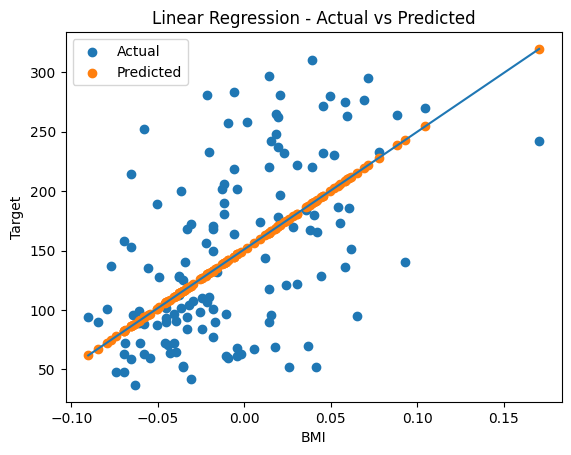

In [ ]:
# b) BIVARIATE ANALYSIS

#linear single regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Single feature
X = sklearn_df[['bmi']]
y = sklearn_df['target']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Prediction
y_pred = lin_reg.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Linear Regression Results (Sklearn Dataset)")
print("Coefficient:", lin_reg.coef_)
print("Intercept:", lin_reg.intercept_)
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mse)
print("RMSE:", rmse)

# -------- Single Graph --------
plt.figure()

# Sort values for clean straight line
sorted_index = X_test['bmi'].argsort()
X_test_sorted = X_test.iloc[sorted_index]
y_test_sorted = y_test.iloc[sorted_index]
y_pred_sorted = y_pred[sorted_index]

# Actual points
plt.scatter(X_test_sorted, y_test_sorted, label="Actual")

# Predicted points
plt.scatter(X_test_sorted, y_pred_sorted, label="Predicted")

# Regression line
plt.plot(X_test_sorted, y_pred_sorted)

plt.xlabel("BMI")
plt.ylabel("Target")
plt.title("Linear Regression - Actual vs Predicted")
plt.legend()
plt.show()

Multiple Linear Regression Results (Sklearn Dataset)
Coefficients: [  29.25401303 -261.7064691   546.29972304  388.39834056 -901.95966819
  506.76324136  121.15435079  288.03526689  659.26895081   41.37670105]
Intercept: 151.00821291456543
R2 Score: 0.4772897164322617
MSE: 2821.750981001311
RMSE: 53.120156070942706


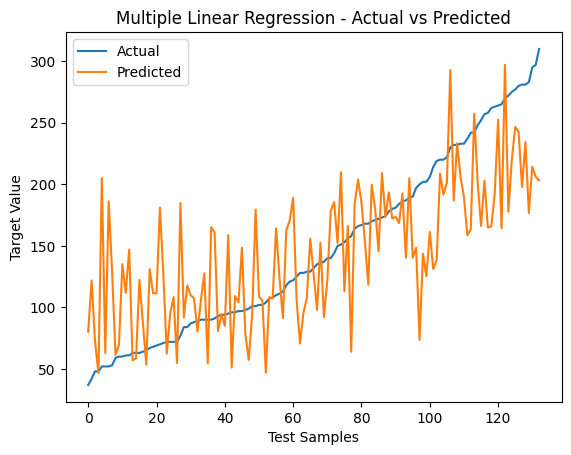

In [ ]:
# b) BIVARIATE ANALYSIS

#linear multiple regression

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Use ALL features
X = sklearn_df.drop('target', axis=1)
y = sklearn_df['target']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Prediction
y_pred = lin_reg.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Multiple Linear Regression Results (Sklearn Dataset)")
print("Coefficients:", lin_reg.coef_)
print("Intercept:", lin_reg.intercept_)
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mse)
print("RMSE:", rmse)

# -------- Single Graph (Actual vs Predicted) --------
plt.figure()

# Sort values for clean visualization
sorted_index = y_test.argsort()
y_test_sorted = y_test.iloc[sorted_index]
y_pred_sorted = y_pred[sorted_index]

# Actual values
plt.plot(y_test_sorted.values, label="Actual")

# Predicted values
plt.plot(y_pred_sorted, label="Predicted")

plt.xlabel("Test Samples")
plt.ylabel("Target Value")
plt.title("Multiple Linear Regression - Actual vs Predicted")
plt.legend()
plt.show()

Logistic Regression (Single Feature - BMI)
Accuracy: 0.007518796992481203
Confusion Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


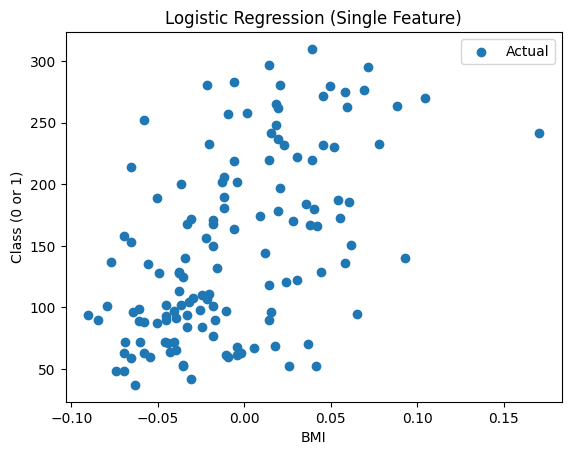

In [ ]:
#logistic single regression

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Single feature
X = sklearn_df[['bmi']]
y = sklearn_df['target']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Prediction
y_pred = log_reg.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression (Single Feature - BMI)")
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# -------- Single Graph --------
plt.figure()

sorted_index = X_test['bmi'].argsort()
X_sorted = X_test.iloc[sorted_index]
y_test_sorted = y_test.iloc[sorted_index]
y_pred_sorted = y_pred[sorted_index]

plt.scatter(X_sorted, y_test_sorted, label="Actual")


plt.xlabel("BMI")
plt.ylabel("Class (0 or 1)")
plt.title("Logistic Regression (Single Feature)")
plt.legend()
plt.show()


Logistic Regression (Multiple Features)
Accuracy: 0.007518796992481203
Confusion Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


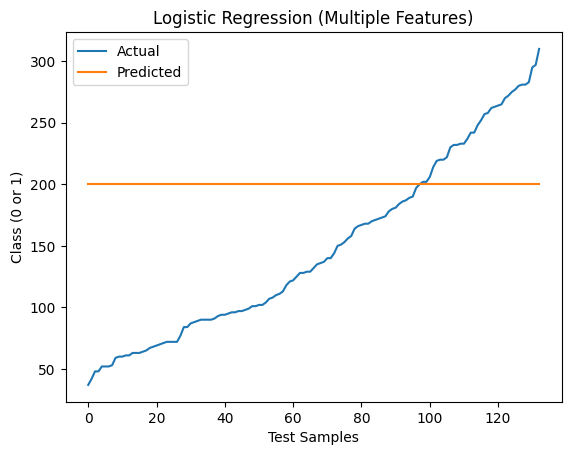

In [ ]:
#logistic multiple regression

# Use ALL features
X = sklearn_df.drop('target', axis=1)
y = sklearn_df['target']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Prediction
y_pred = log_reg.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression (Multiple Features)")
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# -------- Single Graph --------
plt.figure()

sorted_index = y_test.argsort()
y_test_sorted = y_test.iloc[sorted_index]
y_pred_sorted = y_pred[sorted_index]

plt.plot(y_test_sorted.values, label="Actual")
plt.plot(y_pred_sorted, label="Predicted")

plt.xlabel("Test Samples")
plt.ylabel("Class (0 or 1)")
plt.title("Logistic Regression (Multiple Features)")
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score
from sklearn.datasets import load_diabetes

print("========== DATASET 1 : REGRESSION (Sklearn Diabetes) ==========")

# Load sklearn diabetes dataset
diabetes = load_diabetes()
sklearn_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
sklearn_df['target'] = diabetes.target

# -------- Linear Regression (Single Feature) --------
X_single = sklearn_df[['bmi']]
y_reg = sklearn_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X_single, y_reg, test_size=0.3, random_state=42
)

lin_single = LinearRegression()
lin_single.fit(X_train, y_train)
y_pred_single = lin_single.predict(X_test)

r2_single = r2_score(y_test, y_pred_single)
rmse_single = np.sqrt(mean_squared_error(y_test, y_pred_single))

# -------- Linear Regression (Multiple Features) --------
X_multi = sklearn_df.drop('target', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y_reg, test_size=0.3, random_state=42
)

lin_multi = LinearRegression()
lin_multi.fit(X_train, y_train)
y_pred_multi = lin_multi.predict(X_test)

r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print("\nLinear Regression Comparison")
print("Single Feature  -> R2:", r2_single, " RMSE:", rmse_single)
print("Multiple Feature-> R2:", r2_multi, " RMSE:", rmse_multi)

if r2_multi > r2_single:
    print("✔ Multiple Linear Regression performs better")
else:
    print("✔ Single Linear Regression performs better")


print("\n========== DATASET 2 : CLASSIFICATION (Pima Diabetes) ==========")

# Load Pima dataset (Make sure diabetes.csv is in same folder)
pima_df = pd.read_csv("diabetes.csv")

# -------- Logistic Regression (Single Feature) --------
X_single = pima_df[['BMI']]
y_class = pima_df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X_single, y_class, test_size=0.3, random_state=42
)

log_single = LogisticRegression(max_iter=1000)
log_single.fit(X_train, y_train)
y_pred_single = log_single.predict(X_test)

acc_single = accuracy_score(y_test, y_pred_single)

# -------- Logistic Regression (Multiple Features) --------
X_multi = pima_df.drop('Outcome', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y_class, test_size=0.3, random_state=42
)

log_multi = LogisticRegression(max_iter=1000)
log_multi.fit(X_train, y_train)
y_pred_multi = log_multi.predict(X_test)

acc_multi = accuracy_score(y_test, y_pred_multi)

print("\nLogistic Regression Comparison")
print("Single Feature  -> Accuracy:", acc_single)
print("Multiple Feature-> Accuracy:", acc_multi)

if acc_multi > acc_single:
    print("✔ Multiple Logistic Regression performs better")
else:
    print("✔ Single Logistic Regression performs better")


print("\n========== FINAL CONCLUSION ==========")
print("1. Multiple Linear Regression gives higher R2 and lower RMSE.")
print("2. Multiple Logistic Regression gives higher Accuracy.")
print("3. Therefore, using multiple features improves model performance.")

========== DATASET 1 : REGRESSION (Sklearn Diabetes) ==========

Linear Regression Comparison
Single Feature  -> R2: 0.2803417492440603  RMSE: 62.32926055201547
Multiple Feature-> R2: 0.4772897164322617  RMSE: 53.120156070942706
✔ Multiple Linear Regression performs better

========== DATASET 2 : CLASSIFICATION (Pima Diabetes) ==========

Logistic Regression Comparison
Single Feature  -> Accuracy: 0.6536796536796536
Multiple Feature-> Accuracy: 0.7359307359307359
✔ Multiple Logistic Regression performs better

========== FINAL CONCLUSION ==========
1. Multiple Linear Regression gives higher R2 and lower RMSE.
2. Multiple Logistic Regression gives higher Accuracy.
3. Therefore, using multiple features improves model performance.
